# Chapter 5: Data Exploration 2

In [55]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

## 5.1 Introduction

Now we've covered our preliminaries, it's time to start with the second step of data analysis: ***Explorative Analysis***. Here we try to get a first look at our dataset, get a better understanding of it, so we can perform focused analyses later on.


We will also make a conceptual bridge towards probability distributions, samples and populations.

## 5.2 Intent

The goal of descriptive analysis, as the word itself says is to **describe our data**. Like this, we will later on know exactly what we will analyse further. As such, this is the way in which we perform our explorative analysis.

Concretely, ***Univariate Descriptive Analysis*** takes a look at each variable individually. No attention is yet paid to the relationships among variables. For now we simply look at 1 variable, and see exactly how that variable behaves.

Let's start by importing our data, and printing the first 5 observations:

In [56]:
pokemons = pd.read_csv('Pokemon.csv', sep=";")
pokemons.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [57]:
pokemons.dtypes

#              int64
Name          object
Type 1        object
Type 2        object
Total          int64
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Generation     int64
Legendary       bool
dtype: object

By now you should be familiar with the pokemon dataset. To refresh your memory, the dataset contains the following columns:

  * #: ID for each pokemon
  * Name: Name of each pokemon
  * Type 1: Each pokemon has a type, this determines weakness/resistance to attacks
  * Type 2: Some pokemon are dual type and have 2
  * Total: sum of all stats that come after this, a general guide to how strong a pokemon is
  * HP: hit points, or health, defines how much damage a pokemon can withstand before fainting
  * Attack: the base modifier for normal attacks (eg. Scratch, Punch)
  * Defense: the base damage resistance against normal attacks
  * SP Atk: special attack, the base modifier for special attacks (e.g. fire blast, bubble beam)
  * SP Def: the base damage resistance against special attacks
  * Speed: determines which pokemon attacks first each round

In Univariate Descriptive Analysis, we will look at all of these variables individually and check whether they contain information and how they behave. Luckily, as you know from a few lessons ago, pandas provides us with an initial view:

In [58]:
pokemons.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


Remember how before we classified most of this information as 'a bunch of statistical numbers'? Well, now it's time to dive into those numbers!

We can clearly see that only numerical variables are summarized. This makes sense, as no operation can take place on string typed variables.

The first metric we see is **'count'**. This simply states how many observations we have for each variable. We see that all variables have got 800 observations. This is a good sign. Should there be any variable with less observations than the other variable, we have missing values. As seen in the previous lesson, there are 2 main ways to fix missing values:

* The observations with missing variables should be omitted (column or row wise depending on the amount that is missing in each column/row)
* The missing values should be filled (in a smart manner)

The tricky part in this is that 'a smart manner' is not very well defined and will depend on the data and the problem to be solved. 

Secondly, we can observe a **minimum and maximum** value for each variable. This already indicates the range of each variable. For example: the attack value of each pokemon lies somewhere between 5 and 190. This once again makes sense; however, in other datasets we might encounter illogical values such as a negative attack. These observations then need to be filtered out. 

As you can see, this first step already requires common sense and some form of knowledge of the data to avoid working with incorrect or wrong data. Luckily, you possess both!

## 5.3 Graphical Representations

Now we've gotten a broad view of our data, it is time to look at each variable independently. We'll take the example of descriptively analyzing the "Total" variable, but this process should obviously be repeated for every variable!

We'll make our first distribution plot, or "histogram" in order to visualize this variable. On the horizontal axis we will find all possible values of said variable, and on the vertical axis we denote how many times this value has occured.

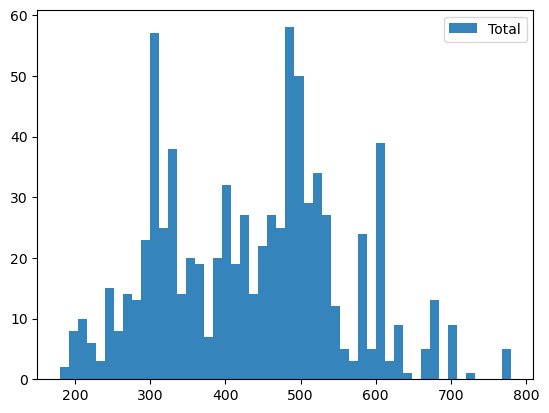

In [59]:
plt.hist(pokemons["Total"], density=False, bins=50, label = 'Total', alpha = 0.9);  
plt.legend()

## 5.4 Numerical Metrics

Obviously, simply plotting variables isn't enough. We do need some kind of objective metrics to represent basic information about our data.

### 5.4.1 Measures of Central Tendency

The first numerical metric we'll take a look at are measures of central tendency. The question we're trying to answer is the following:

"***Where is the center of the data situated?***"

#### Mean

The first, and most straightforward measure of central tendency is the mean, a.k.a. average. It is quite simply calculated as follows:



$$ \overline{x} = \frac{1}{n}\sum_{i=1}^{n}x_{i} = \frac{x_1 + x_2 + \cdots + x_n}{n} $$


The sum of all values is calculated, and is then divided by the amount of observations. Simple as it may be, it is even more straightforward to calculate:

In [60]:
mean = np.mean(pokemons["Total"])
mean

np.float64(435.1025)

In [61]:
pokemons['Total'].mean()

np.float64(435.1025)

From this, we can say that the average Total score of all observations is 435. It is always interesting to compare this with the minimum and maximum values. We see that the average value is about in the middle between the minimum and maximum. 

Is the mean however a good metric of central tendency in our case? Let's plot it against the histogram to check.

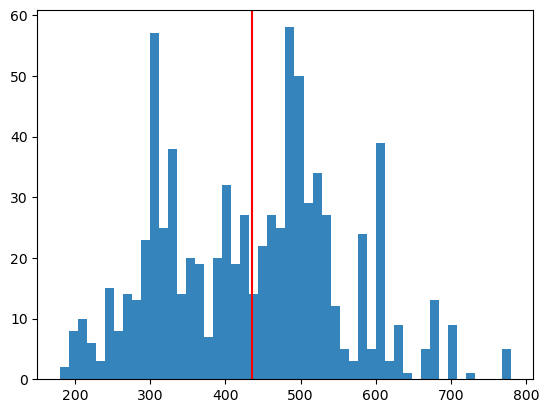

In [62]:
plt.hist(pokemons["Total"], bins = 50, alpha = 0.9)
plt.axvline(mean, 0, 150, color="r")
plt.show()

There are different cases in which the mean is less than optimal. One of those is the presence of outliers: the mean is extremely sensitive to outliers. The median, which we will see later, offers a solution to this. Another issue is multiple peakedness. This is the presence of multiple "centers". This setting is much harder to describe and needs to be detected graphically.

In our histogram, we can clearly see two centers: one around 500, and one around 300. Together with the values between these two, the center of our variable is formed. As such, the mean is in this case a fairly good measure. It may however be interesting to also calculate the mode and the mean. 

#### Question 1: Is the mean meaningful for all numeric data?

Think back to the data classes we've seen before!

The data needs to be continuous for the mean to be meaningful. If data is discrete (for example, a score out of 20), a mean of 16.3 is possible but would be meaningless.

#### Median

The median is the second measure of central tendency we *always* calculate when studying a variable. It is calculated fairly easily: we'll put all our observations next to each other in an ordered fashion. We then simply pick the middle one. As such, it is also extremely easy to calculate:

In [63]:
median = np.median(pokemons["Total"])
print(median)

450.0


As we have mentioned above, the median is much more robust against outliers. When comparing, we can see that our mean and median are quite close together. This indicates that 

1. There are not much outliers, if any
2. The distribution is more or less symmetric

Let's see if we can check that in the histogram:

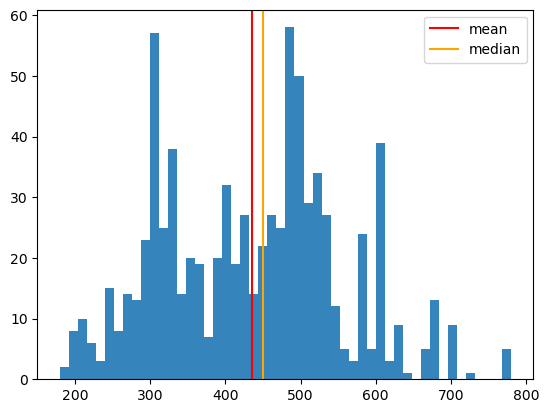

In [64]:
plt.hist(pokemons["Total"], bins = 50, alpha = 0.9)
plt.axvline(pokemons["Total"].mean(), 0, 150, label = "mean", color = "red")
plt.axvline(pokemons["Total"].median(), 0, 150, label = "median", color = "orange")
plt.legend()
plt.show()

We indeed see that the mean and median are really close together. We have obtained an additional indication that the center of our data is indeed somewhere around 435-450. If these two measures fall more or less together, it's a first evidence that we have indeed found the center of our dataset.

### 5.4.2 Measures of Dispersion

Next to getting an idea of where the center of our data is, it might be interesting to get a formal idea about how "spread out" our data is. The question we ask ourselves is the following:

"***If we were to take a random observation, how far away would it lie from the center of the data?***"

#### Variance

The first measures of dispersion is are the variance and standard deviation. These measures are build on top of the mean, and as such can only be calculated for the variable types for which we can calculate the mean!

When calculating the variance, we first calculate for each observation the distance it lies from the mean. We then simply take the average of all these distances. As such, it represents the average distance from the mean.

The formula is as follows:

$$ S^2 = 
            \frac{\sum_{i=1}^n(x_i - \overline{x})^2}{n-1} $$
            
            
$$ StdDev = 
            \sqrt{S^2} = S $$  

It is clear that the standard deviation and the variance contain the exact same information. As such, we only need to calculate one of both!

In [65]:
variance = np.var(pokemons["Total"])
stdev = np.sqrt(variance)
print(stdev)

119.88803941073523


We conclude that on average, an observation will lie about 120 points away from the mean. There will definitely also be points closer to the mean and points farther away from the mean. This is simply a general metric that indicates the average distance from the mean. Additionally, it tells us nothing about which side of the mean an observation will lie on. It simply shows us how dispersed our data is.

#### Percentiles

The second measure of dispersion are the percentiles. Remember when we calculated the median, that we first ordered all our observations and then picked the middle one. This implies that there exist exactly 50% of our observations left from the median, and the other half of our dataset will be higher than the median. Percentiles are nothing more than a generalization of this concept. Rather than cutting our dataset in 2 parts by selecting the middle value, we can cut our dataset in 2 by selecting a certain percentage of observations the number must cut.

For example: the 1st percentile is the number for which 1% of our observations is lower, and 99% of our dataset is higher. As such, the median can be seen as the 50th percentile.

Let's calculate some percentiles:

In [66]:
percentile_01 = np.percentile(pokemons["Total"], 1)
percentile_99 = np.percentile(pokemons["Total"], 99)
median = np.percentile(pokemons["Total"], 50)

print(f"percentile 1: {percentile_01}")
print(f"percentile 99: {percentile_99}")
print(f"median: {median}")

percentile 1: 200.0
percentile 99: 700.0
median: 450.0


From this, we can say that 99% of all observations are higher than 200. In other words, 1% of the observations are lower than 200, so it's not quite the minimum value.
We can also see that 99% of all observations remain under 700, with 1% being higher than 700.
Furthermore, when looking at the 50th percentile, we get a familiar number: our median! This makes sense, as when we pick the middle value, this will be exactly at 50%.

A few special percentiles:

* $Q1$ = the 25th percentile
* $Q2$ = the 50th percentile (the median)
* $Q3$ = the 75th percentile

There is also the **interquartile range (IQR)**, which is a measure of dispersion based on the percentiles/quartiles: $IQR$ = $Q_3$ − $Q_1$

These quartiles are used to construct the box in the boxplot:

![boxplot info](https://media.geeksforgeeks.org/wp-content/uploads/20260115114655635407/box_plot_.webp)

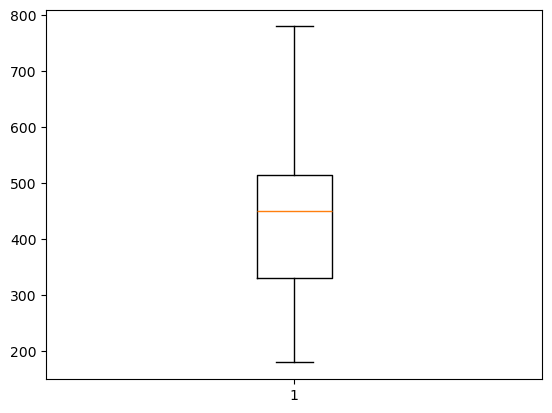

In [67]:
plt.boxplot(pokemons["Total"])
plt.show()

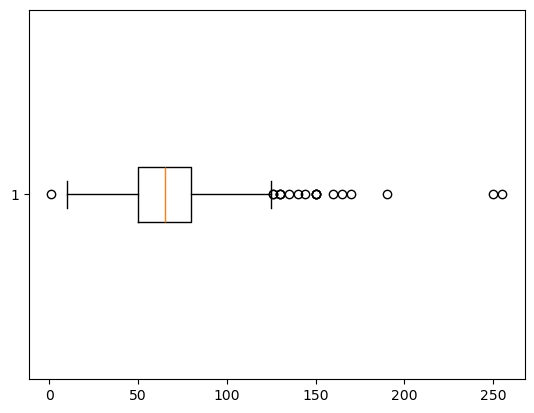

In [68]:
plt.boxplot(pokemons["HP"], vert = False)
plt.show()

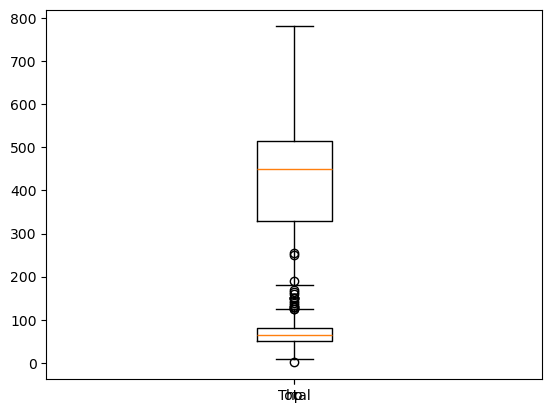

In [69]:
plt.boxplot(pokemons["HP"], tick_labels = ["hp"])
plt.boxplot(pokemons["Total"], tick_labels = ["Total"])
plt.show()

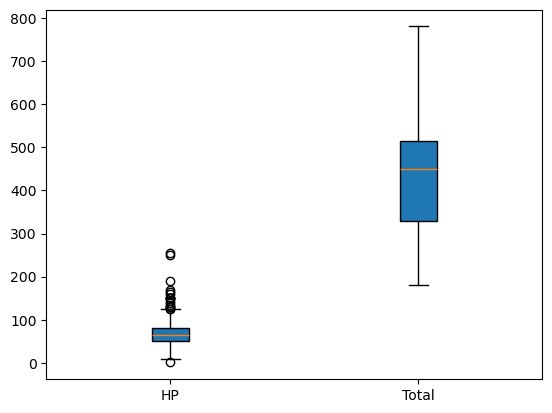

In [70]:
boxplot_data_list = [pokemons["HP"],
                    pokemons["Total"]]

boxplot_data_labels = ['HP', "Total"]

plt.boxplot(boxplot_data_list, tick_labels = boxplot_data_labels, patch_artist=True);

Other measures also exist. For example, **Kurtosis** measures how peaked or flat a distribution is (whether it has sharp peaks or is more spread out). We won't explore these measures in depth here.

### 5.4.3 Exercises

#### Question 2: Boxplots vs Histograms

Compare the variables 'Total', 'HP', and 'Generation'. Which of these variables has the highest/lowest mean, median, and standard deviation? Solve this question by making two different visualizations:

1. Histograms
2. Boxplots

Do you prefer one visualization over the other, and why?

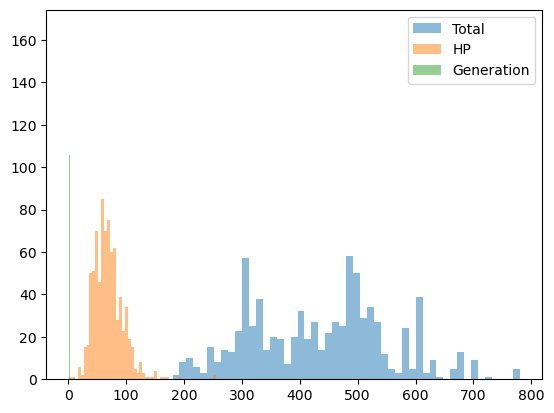

In [71]:
plt.hist(pokemons["Total"], density=False, bins=50, label = 'Total', alpha = 0.5);  # density=False would make counts
plt.hist(pokemons["HP"], density=False, bins=50, label = 'HP', alpha = 0.5);  # density=False would make counts
plt.hist(pokemons["Generation"], density=False, bins=50, label = 'Generation', alpha = 0.5);  # density=False would make counts
plt.legend()
plt.show()

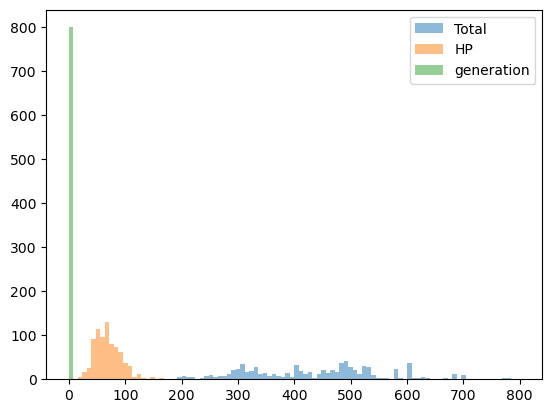

In [72]:
plt.hist(pokemons["Total"], density=False, bins=100, range = [0,800], label = 'Total', alpha = 0.5);  # density=False would make counts
plt.hist(pokemons["HP"], density=False, bins=100, range = [0,800], label = 'HP', alpha = 0.5);  # density=False would make counts
plt.hist(pokemons["Generation"], density=False, bins=100, range = [0,800], label = 'generation', alpha = 0.5);  # density=False would make counts
plt.legend()
plt.show()

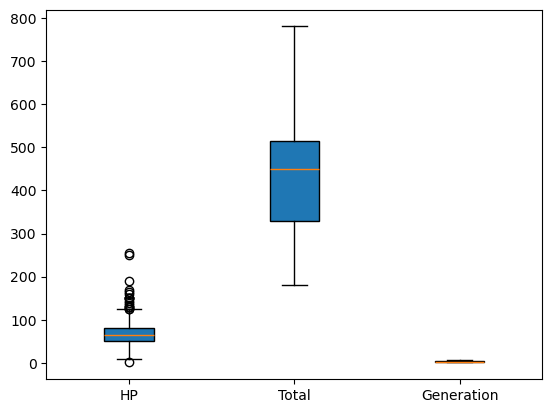

In [73]:
boxplot_data_list = [pokemons["HP"],
                    pokemons["Total"],
                    pokemons["Generation"]]

boxplot_data_labels = ['HP', "Total", "Generation"]

plt.boxplot(boxplot_data_list, tick_labels = boxplot_data_labels, patch_artist=True);

In general, it's difficult to get a clear picture of the 'Generation' data since it operates on such a small scale compared to the other variables. Especially in the boxplot, it becomes unreadable. While having separate plots would be a better solution, in this case a histogram might be preferred.

#### Question 3: Boxplots vs Histograms (Part 2)

Do the same as the exercise above but compare the variables 'HP', 'Attack', 'Defense', and 'Speed'. 

Which type of visualization do you prefer in this case?

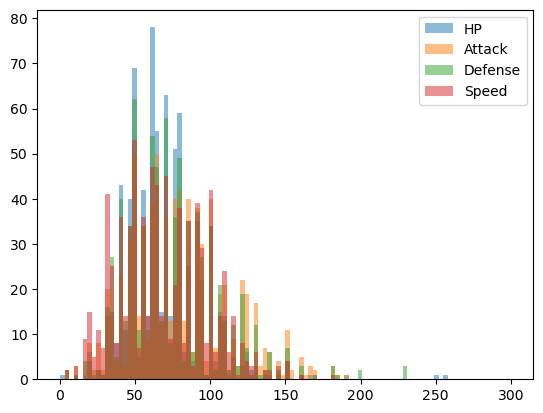

In [74]:
plt.hist(pokemons["HP"], density=False, bins=100, range = [0,300], label = 'HP', alpha = 0.5);  # density=False would make counts
plt.hist(pokemons["Attack"], density=False, bins=100, range = [0,300], label = 'Attack', alpha = 0.5);  # density=False would make counts
plt.hist(pokemons["Defense"], density=False, bins=100, range = [0,300], label = 'Defense', alpha = 0.5);  # density=False would make counts
plt.hist(pokemons["Speed"], density=False, bins=100, range = [0,300], label = 'Speed', alpha = 0.5);  # density=False would make counts
plt.legend()
plt.show()

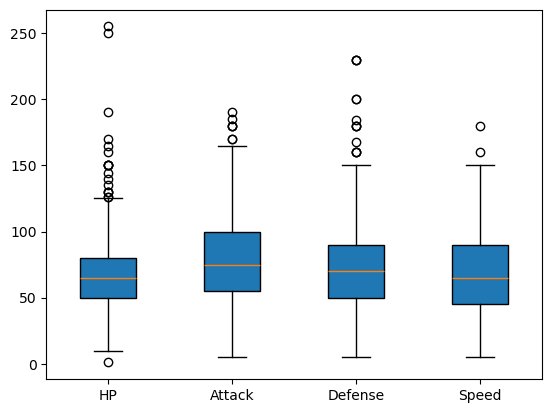

In [75]:
boxplot_data_list = [pokemons["HP"],
                    pokemons["Attack"],
                    pokemons["Defense"],
                    pokemons["Speed"]]

boxplot_data_labels = ['HP', "Attack", "Defense", "Speed"]

plt.boxplot(boxplot_data_list, tick_labels = boxplot_data_labels, patch_artist=True);

In this case, all variables are at the same scale. That's great, but not ideal when looking at the histogram. With overlapping data, it becomes unreadable. Here a boxplot becomes more useful to get an accurate sense of each variable.

# 5.5 Sample vs population

To conceptually understand a large number of 'stuff going on' in statistics, it is important to understand the difference between a sample and a population. 

- Population = The entire 'population' of individuals you wish to make conclusions for. This can be pokemon, but also people or laptops.
- Sample = The part of the population you have measurements of.

#### Question 4: Why is this difference so crucial? 

Often you will find it is not possible to calculate statistics on the entire population (too large, too expensive, etc.). So a sample is taken on which to calculate statistics, allowing us to make conclusions about the entire population.

Note: The population is almost completely defined by the question or problem at hand.

#### Question 5: Let's check the effect of this sample size by making a visualisation of some HP stats.

Make a figure which illustrate the effect of sample size on the average HP of that sample. For each possible sample size show the mean, as well as the standard deviation. Create a plot that shows the evolution over all sample sizes. Also show the average.

In [ ]:
size_list = range(1, 801)
mean_sample = []
sd_sample = []

for sample_size in size_list:
    mean_sample.append(pokemons["HP"].sample(sample_size).mean())
    sd_sample.append(pokemons["HP"].sample(sample_size).std())

Sample_simulation = pd.DataFrame({'sample_size': size_list, 'sample_mean': mean_sample, 'sample_sd': sd_sample}) 
Sample_simulation.head(10)

,sample_size,sample_mean,sample_sd
0,1,100.000000,NaN
1,2,57.500000,24.748737
2,3,55.000000,41.932485
3,4,49.000000,12.583057
4,5,60.000000,32.182293
5,6,73.000000,28.939592
6,7,72.142857,29.461032
7,8,64.625000,24.617067
8,9,67.444444,22.159147
9,10,78.100000,27.326015


In [84]:
print(pokemons["HP"].mean())

69.25875


In [83]:
Sample_simulation.tail(10)

,sample_size,sample_mean,sample_sd
790,791,69.241466,25.539477
791,792,69.045455,25.566637
792,793,69.259773,25.601723
793,794,69.243073,25.495467
794,795,69.150943,25.501212
795,796,69.335427,25.542764
796,797,69.318695,25.508406
797,798,69.249373,25.561752
798,799,69.257822,25.548558
799,800,69.258750,25.534669


Higher the amount of samples, closer to the real mean is.

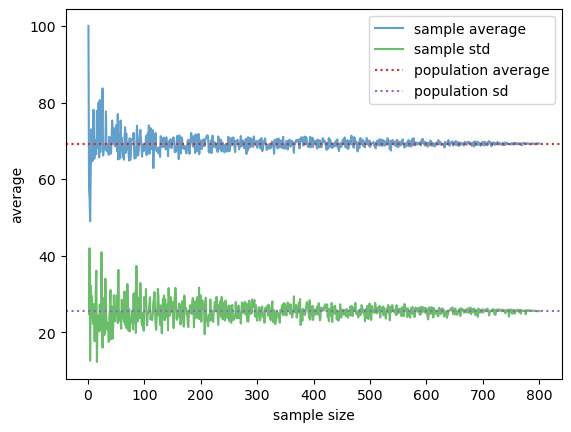

In [77]:
plt.plot(Sample_simulation['sample_size'], Sample_simulation['sample_mean'], color = 'tab:blue', label='sample average', alpha=0.7)
plt.plot(Sample_simulation['sample_size'], Sample_simulation['sample_sd'], color = 'tab:green', label='sample std', alpha=0.7)
plt.axhline(pokemons["HP"].mean(), color = 'tab:red', linestyle = "dotted", label = "population average")
plt.axhline(np.sqrt(np.var(pokemons["HP"])), color = 'tab:purple', linestyle = "dotted", label = "population sd")
plt.ylabel("average")
plt.xlabel("sample size")
plt.legend()

#### Teaser: Stratified Sampling

##### Manual approach:

In [90]:
# Stratified sampling based on HP column: Divide HP into 3 strata (low, medium, high) and sample proportionally
# Define strata based on HP quantiles
pokemons['HP_strata'] = pd.qcut(pokemons['HP'], q=3, labels=['low', 'medium', 'high'])

# Sample 10% from each stratum
stratified_sample = pokemons.groupby('HP_strata', group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))

# Display the sample
stratified_sample.head()

C:\Users\billo\AppData\Local\Temp\ipykernel_24460\4142468700.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stratified_sample = pokemons.groupby('HP_strata', group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))
C:\Users\billo\AppData\Local\Temp\ipykernel_24460\4142468700.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = pokemons.groupby('HP_strata', group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,HP_strata,hp_bins
69,64,Kadabra,Psychic,NaN,400,40,35,30,120,70,105,1,False,low,Q1
304,281,Kirlia,Psychic,Fairy,278,38,35,35,65,55,50,3,False,low,Q1
202,187,Hoppip,Grass,Flying,250,35,35,40,35,55,50,2,False,low,Q1
330,304,Aron,Steel,Rock,330,50,70,100,40,40,30,3,False,low,Q1
574,515,Panpour,Water,NaN,316,50,53,48,53,48,64,5,False,low,Q1


In [92]:
# Compare the median of the sample with the population median

print(stratified_sample['HP'].median())
print(pokemons['HP'].median())

65.5
65.0


##### Using the sklearn module:

In [85]:
from sklearn.model_selection import train_test_split

# Step 1: Create bins for HP (e.g., Low, Mid, High)
# This creates the "strata" needed for the sampling
pokemons['hp_bins'] = pd.qcut(pokemons['HP'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Step 2: Stratified Sampling
# test_size=0.2 gives you a 20% sample
strat_sample, _ = train_test_split(
    pokemons, 
    test_size=0.8,      # We keep 20% by "splitting" 80% away
    stratify=pokemons['hp_bins'], 
    random_state=42
)

# Drop the helper column
strat_sample = strat_sample.drop(columns=['hp_bins'])

# Compare the median of the sample with the population median
print(strat_sample['HP'].median())
print(pokemons['HP'].median())

65.0
65.0
